<a href="https://www.kaggle.com/code/antoninast/fruits-homework-1-10?scriptVersionId=354906548" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
from torchvision.datasets import ImageFolder

In [2]:
data_fruits = "/kaggle/input/datasets/sshikamaru/fruit-recognition/train/train"
dataset = ImageFolder(data_fruits)

In [3]:
len(dataset)

16854

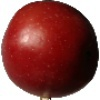

In [4]:
img, label = dataset[100]
img

In [5]:
dataset.classes

['Apple Braeburn',
 'Apple Granny Smith',
 'Apricot',
 'Avocado',
 'Banana',
 'Blueberry',
 'Cactus fruit',
 'Cantaloupe',
 'Cherry',
 'Clementine',
 'Corn',
 'Cucumber Ripe',
 'Grape Blue',
 'Kiwi',
 'Lemon',
 'Limes',
 'Mango',
 'Onion White',
 'Orange',
 'Papaya',
 'Passion Fruit',
 'Peach',
 'Pear',
 'Pepper Green',
 'Pepper Red',
 'Pineapple',
 'Plum',
 'Pomegranate',
 'Potato Red',
 'Raspberry',
 'Strawberry',
 'Tomato',
 'Watermelon']

In [6]:
label

0

In [7]:
from torchvision import transforms

train_transformer = transforms.Compose([
       transforms.Resize([100, 100]), 
       transforms.RandomHorizontalFlip(p=0.5),  
       transforms.RandomRotation(10),   
       transforms.ToTensor()   
])

In [8]:
train_transformer(img)

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])

In [9]:
test_transformer = transforms.Compose([
       transforms.Resize([100, 100]),   
       transforms.ToTensor()   
])

In [10]:
from torch.utils.data import random_split
train_dataset, test_dataset = random_split(dataset, [0.8, 0.2])

In [11]:
len(train_dataset)

13484

In [12]:
len(test_dataset)

3370

In [13]:
train_dataset[1]

(<PIL.Image.Image image mode=RGB size=100x100>, 14)

In [14]:
from torch.utils.data import Dataset

In [15]:
class TransformDatasetFruits(Dataset):
    def __init__(self, dataset, transformer):
        super().__init__()
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        img_new = self.transformer(img)

        return img_new, label

In [16]:
train_dataset = TransformDatasetFruits(train_dataset, train_transformer)
test_dataset = TransformDatasetFruits(test_dataset, test_transformer)

In [17]:
train_dataset[0]

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 2)

In [18]:
from torch.utils.data import DataLoader

In [19]:
train_loader = DataLoader(train_dataset, batch_size=200)
test_loader = DataLoader(test_dataset, batch_size=200)

In [20]:
for img, labels in train_loader:
    break

In [21]:
labels

tensor([ 2, 14,  7, 18, 27,  4, 24, 23, 14, 11,  4, 22, 27, 12, 29,  8, 30,  2,
         0,  5,  9, 14,  5, 22, 26, 12, 12,  1, 12, 24, 24, 14,  5,  6, 31, 17,
        12, 22, 10, 11,  8, 14, 21,  4, 12, 15, 28, 13, 16, 31, 26, 14,  8,  7,
        24, 32, 13, 22,  2,  9, 24,  4, 32, 15, 30, 10, 19, 13, 28, 17, 24, 32,
         4, 17, 24,  2,  6, 31, 13, 21,  0, 15, 25, 10, 22, 26, 30, 14, 27, 27,
        31,  1, 18, 23,  3, 12, 27, 27, 18, 10,  5, 24, 31, 19,  1, 12, 12, 10,
        32,  5,  5, 18, 31, 22, 25, 22,  8, 19,  6, 30,  7, 32,  7,  8,  4, 10,
        17, 30, 19, 30,  9,  1, 21, 28, 25, 25, 20, 23, 14, 30, 12,  6, 11, 10,
         1,  6, 12, 29, 14, 13, 27, 11, 21, 23, 21, 12, 10, 23, 16,  0,  8, 30,
        23, 21,  0, 32, 27, 12, 29, 26,  0,  7, 29, 15, 16, 13, 11,  0, 18, 18,
        25, 31,  6, 21,  9, 30, 22, 26, 25, 25, 27,  8,  1, 25, 24,  9,  4, 23,
        26,  4])

In [22]:
img.shape

torch.Size([200, 3, 100, 100])

In [23]:
from torch import nn

In [24]:
dataset.classes

['Apple Braeburn',
 'Apple Granny Smith',
 'Apricot',
 'Avocado',
 'Banana',
 'Blueberry',
 'Cactus fruit',
 'Cantaloupe',
 'Cherry',
 'Clementine',
 'Corn',
 'Cucumber Ripe',
 'Grape Blue',
 'Kiwi',
 'Lemon',
 'Limes',
 'Mango',
 'Onion White',
 'Orange',
 'Papaya',
 'Passion Fruit',
 'Peach',
 'Pear',
 'Pepper Green',
 'Pepper Red',
 'Pineapple',
 'Plum',
 'Pomegranate',
 'Potato Red',
 'Raspberry',
 'Strawberry',
 'Tomato',
 'Watermelon']

In [25]:
print(len(dataset.classes))

33


In [26]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(30000, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 33)
)


In [27]:
for x,y in train_loader:
    break

In [28]:
x.shape

torch.Size([200, 3, 100, 100])

In [29]:
model(x)

tensor([[ 0.0203, -0.1569,  0.0266,  ..., -0.0399,  0.0246,  0.1336],
        [ 0.0267, -0.1658,  0.0334,  ..., -0.0551,  0.0339,  0.1422],
        [ 0.0392, -0.1519,  0.0233,  ..., -0.0417,  0.0354,  0.1336],
        ...,
        [ 0.0348, -0.1500,  0.0149,  ..., -0.0266,  0.0426,  0.1408],
        [ 0.0292, -0.1475,  0.0227,  ..., -0.0239,  0.0307,  0.1350],
        [ 0.0425, -0.1496,  0.0261,  ..., -0.0374,  0.0309,  0.1372]],
       grad_fn=<AddmmBackward0>)

In [31]:
from torch.optim import Adam 

loss_fn = nn.CrossEntropyLoss()

optimizer = Adam(
    model.parameters(),
    lr=0.0001,
)

In [32]:
device = "cpu"

model = model.to(device)

In [33]:
for x,y in train_loader:
    X = x.to(device)
    Y = y.to(device)
    y_pred = model(x)
    loss = loss_fn(y_pred, y)
    print(loss)

loss.backward()
optimizer.step()
optimizer.zero_grad()

tensor(3.5120, grad_fn=<NllLossBackward0>)
tensor(3.4992, grad_fn=<NllLossBackward0>)
tensor(3.5145, grad_fn=<NllLossBackward0>)
tensor(3.5038, grad_fn=<NllLossBackward0>)
tensor(3.5152, grad_fn=<NllLossBackward0>)
tensor(3.5025, grad_fn=<NllLossBackward0>)
tensor(3.4901, grad_fn=<NllLossBackward0>)
tensor(3.5040, grad_fn=<NllLossBackward0>)
tensor(3.4892, grad_fn=<NllLossBackward0>)
tensor(3.5007, grad_fn=<NllLossBackward0>)
tensor(3.5026, grad_fn=<NllLossBackward0>)
tensor(3.5106, grad_fn=<NllLossBackward0>)
tensor(3.4946, grad_fn=<NllLossBackward0>)
tensor(3.5002, grad_fn=<NllLossBackward0>)
tensor(3.5039, grad_fn=<NllLossBackward0>)
tensor(3.5097, grad_fn=<NllLossBackward0>)
tensor(3.5030, grad_fn=<NllLossBackward0>)
tensor(3.5133, grad_fn=<NllLossBackward0>)
tensor(3.5182, grad_fn=<NllLossBackward0>)
tensor(3.5151, grad_fn=<NllLossBackward0>)
tensor(3.5015, grad_fn=<NllLossBackward0>)
tensor(3.5094, grad_fn=<NllLossBackward0>)
tensor(3.5095, grad_fn=<NllLossBackward0>)
tensor(3.50

In [49]:
epochs = 5
list_lost_train = []
list_lost_test = []

for i in range(epochs):
    for x_batch, y_batch in train_loader:
        X_batch = x_batch.to(device)
        Y_batch = y_batch.to(device)

        y_pred = model(X_batch)

        loss = loss_fn(y_pred, y_batch)
        list_lost_train.append(loss.item())

        print(loss.item())

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    for x_batch, y_batch in test_loader:
        X_batch = x_batch.to(device)
        Y_batch = y_batch.to(device)
        y_pred = model(X_batch)

        loss = loss_fn(y_pred, y_batch)
        list_lost_test.append(loss.item())
        

1.078762412071228
1.0053071975708008
1.0363296270370483
1.0398672819137573
0.9984514117240906
1.0136152505874634
0.9608012437820435
1.0786291360855103
0.9948758482933044
0.9458916187286377
0.9658380150794983
1.041214942932129
1.0052156448364258
0.9126178622245789
0.8802212476730347
0.8012303113937378
1.0568360090255737
1.0357242822647095
1.0407836437225342
0.8713645339012146
0.8292105793952942
1.019197702407837
0.8802189826965332
0.9362016916275024
1.038500189781189
0.9636834859848022
0.8785288333892822
0.9099314212799072
0.8606036305427551
0.852963387966156
0.867790937423706
0.9360308051109314
0.9379231333732605
0.8590066432952881
0.8711395859718323
0.8104740977287292
0.9570201635360718
0.9090765118598938
0.8045384287834167
0.8414614796638489
0.8722622394561768
0.8794392943382263
0.8979132771492004
0.8916168212890625
0.855918288230896
0.8032553195953369
0.7353073954582214
0.8515418171882629
0.8678473830223083
0.8835948705673218
0.8210857510566711
0.7830424308776855
0.8972570300102234


In [41]:
list_lost_train

[1.5339384078979492,
 1.389559268951416,
 1.483261227607727,
 1.447678804397583,
 1.492303490638733,
 1.4882020950317383,
 1.4307125806808472,
 1.4589141607284546,
 1.4400224685668945,
 1.34201979637146,
 1.359971046447754,
 1.471154808998108,
 1.3992571830749512,
 1.3717143535614014,
 1.2771474123001099,
 1.206907868385315,
 1.4817432165145874,
 1.4257748126983643,
 1.4396240711212158,
 1.2542884349822998,
 1.193922519683838,
 1.4415301084518433,
 1.2841746807098389,
 1.3189839124679565,
 1.404768943786621,
 1.3382809162139893,
 1.2785706520080566,
 1.2891215085983276,
 1.2234307527542114,
 1.200960636138916,
 1.227461576461792,
 1.3093299865722656,
 1.3596453666687012,
 1.1925692558288574,
 1.208156704902649,
 1.184626817703247,
 1.3246272802352905,
 1.2410231828689575,
 1.1804026365280151,
 1.2145100831985474,
 1.21004056930542,
 1.238185167312622,
 1.2727463245391846,
 1.1958199739456177,
 1.1540515422821045,
 1.1188180446624756,
 1.0568615198135376,
 1.1734592914581299,
 1.2129997

In [50]:
for i in range(len(list_lost_train)):
    list_lost_train[i] = list_lost_train[i]

In [51]:
for i in range(len(list_lost_test)):
    list_lost_test[i] = list_lost_test[i]

In [47]:
list_lost_test

[0.9814890027046204,
 1.0301120281219482,
 1.01553475856781,
 1.031798243522644,
 1.0435720682144165,
 0.9513413310050964,
 1.0491690635681152,
 1.064513921737671,
 0.931907594203949,
 1.0156821012496948,
 1.0724719762802124,
 0.9741748571395874,
 1.0020875930786133,
 0.9615517258644104,
 0.9844815135002136,
 0.9220213294029236,
 0.9131993055343628]

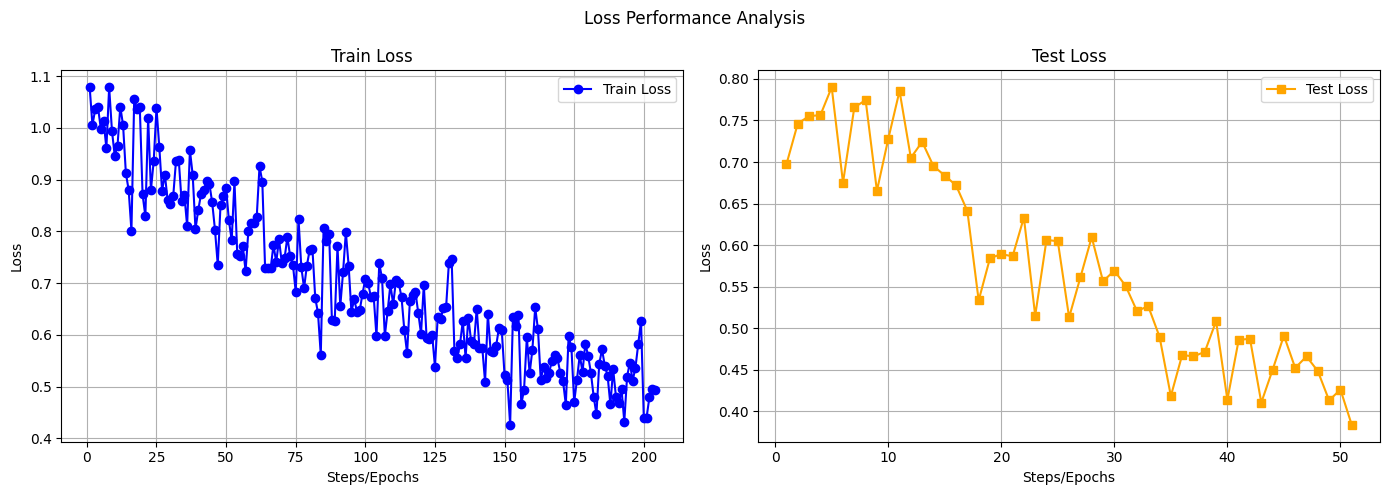

In [52]:
import matplotlib.pyplot as plt

# Окремі кроки для кожного графіка
step_train = range(1, len(list_lost_train) + 1)
step_test = range(1, len(list_lost_test) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Передаємо step_train (довжина 24)
ax1.plot(step_train, list_lost_train, label='Train Loss', color='blue', marker='o')
ax1.set_title('Train Loss')
ax1.set_xlabel('Steps/Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Передаємо step_test (довжина 6)
ax2.plot(step_test, list_lost_test, label='Test Loss', color='orange', marker='s')
ax2.set_title('Test Loss')
ax2.set_xlabel('Steps/Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.suptitle('Loss Performance Analysis')
plt.tight_layout()
plt.show()